# Practical Session 06a &mdash; The maximum margin and the soft margin

**Companion to Lecture&nbsp;06.** First of three notebooks shared by Sessions&nbsp;06 and&nbsp;07.

| # | Notebook | Topic |
|---|----------|-------|
| **06a** | **The margin and the soft margin** | **the widest band, support vectors, $C$, the hinge (this notebook)** |
| 06b | The dual and the kernel trick | the prices $\alpha_i$, KKT, inner products only &mdash; *the bridge to Session&nbsp;07* |
| 07 | Kernels in practice | valid kernels, the zoo, $\gamma$, kernel ridge regression |

When two classes can be separated by a straight line, they can be separated by **infinitely many**
lines, and every one of them scores 100% on the training data. The support vector machine picks the
one with the **widest empty band** around it &mdash; the line that leaves the most room for error.

In this notebook scikit-learn's `SVC` does the fitting, and *we* check every geometric claim of the
lecture with a few lines of NumPy.

> &#11088; **Key idea.** With the score $f(\mathbf{x})=\mathbf{w}^\top\mathbf{x}+b$, the SVM solves
> $\min_{\mathbf{w},b}\tfrac12\lVert\mathbf{w}\rVert^2$ subject to $y_if(\mathbf{x}_i)\ge1$ for every
> point, and the band between the lines $f=-1$ and $f=+1$ is exactly $2/\lVert\mathbf{w}\rVert$ wide.

> &#9888;&#65039; **One change from Session&nbsp;04.** Labels are $y_i\in\{-1,+1\}$ here, not $\{0,1\}$,
> so that $y_if(\mathbf{x}_i)>0$ means "classified correctly" for **either** class.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

from nb_utils import use_style
from nb_data import make_two_blobs

use_style("notes")
C0, C1, CG = "#0072B2", "#D55E00", "#009E73"      # class -1, class +1, the boundary


def score(X, w, b):
    "the SVM score f(x) = w.x + b, for every row of X"
    return X @ w + b


def draw_svm(ax, X, y, w, b, sv=None, title="", pad=0.8):
    "points, the boundary f=0 (solid), the margin lines f=+-1 (dashed), support vectors circled"
    gx, gy = np.meshgrid(np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 300),
                         np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 300))
    F = score(np.column_stack([gx.ravel(), gy.ravel()]), w, b).reshape(gx.shape)
    ax.contourf(gx, gy, F, levels=[-1, 1], colors=[CG], alpha=0.12)
    ax.contour(gx, gy, F, levels=[-1, 0, 1], colors=["0.35", CG, "0.35"],
               linestyles=["--", "-", "--"], linewidths=[1.4, 2.4, 1.4])
    for lab, c in ((-1, C0), (1, C1)):
        ax.scatter(*X[y == lab].T, s=28, color=c, edgecolor="white", linewidth=0.4, zorder=3)
    if sv is not None:
        ax.scatter(*X[sv].T, s=160, facecolor="none", edgecolor="black", linewidth=1.3, zorder=4)
    ax.set_aspect("equal"); ax.set_title(title, fontsize=10)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

print("ready")

ready


## 1. Three points you can solve by hand

Lecture&nbsp;06 solved this tiny problem on paper: $\mathbf{x}_1=(2,0)$ and $\mathbf{x}_2=(0,2)$ are
labeled $+1$, $\mathbf{x}_3=(0,0)$ is labeled $-1$. The answer was $\mathbf{w}=(1,1)$, $b=-1$, the
boundary $x_1+x_2=1$, and a band $\sqrt2$ wide.

Two margins describe how well a point is classified:

| name | formula | what it measures |
|---|---|---|
| **functional** margin | $\hat\gamma_i=y_i\,f(\mathbf{x}_i)$ | the score, signed by the label &mdash; **no units** |
| **geometric** margin | $\gamma_i=y_i\,f(\mathbf{x}_i)/\lVert\mathbf{w}\rVert$ | a real **distance** to the boundary |

Let us check the lecture's answer, then ask scikit-learn for its own.

functional margins y*f(x): [1. 1. 1.]
geometric margins        : [0.7071 0.7071 0.7071]   (each 1/sqrt(2))
band width 2/||w||       : 1.4142   (sqrt(2))

sklearn  w: [0.99951 0.99951]   b: -0.99935
support vectors (row indices): [2 0 1]


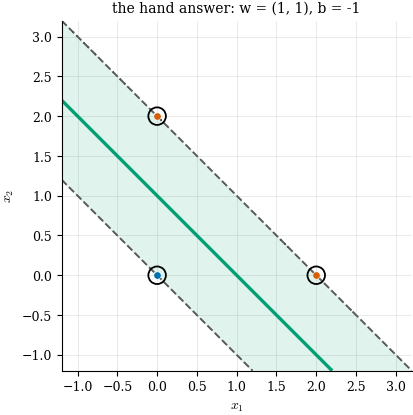

In [2]:
X3 = np.array([[2.0, 0.0], [0.0, 2.0], [0.0, 0.0]])
y3 = np.array([1, 1, -1])

w_hand, b_hand = np.array([1.0, 1.0]), -1.0
func = y3 * score(X3, w_hand, b_hand)                  # functional margins
geo = func / np.linalg.norm(w_hand)                    # geometric margins
print("functional margins y*f(x):", func)
print("geometric margins        :", geo.round(4), "  (each 1/sqrt(2))")
print("band width 2/||w||       :", round(2 / np.linalg.norm(w_hand), 4), "  (sqrt(2))")

svm3 = SVC(kernel="linear", C=1e6).fit(X3, y3)         # a large C asks for the hard margin (any C >= 1 would do here)
print("\nsklearn  w:", svm3.coef_[0].round(5), "  b:", round(float(svm3.intercept_[0]), 5))
print("support vectors (row indices):", svm3.support_)

fig, ax = plt.subplots(figsize=(4.6, 4.2))
draw_svm(ax, X3, y3, w_hand, b_hand, sv=svm3.support_,
         title="the hand answer: w = (1, 1), b = -1", pad=1.2)
plt.show()

Every functional margin is exactly $1$: all three constraints $y_if(\mathbf{x}_i)\ge1$ are **tight**,
so all three points sit on a dashed line and all three are **support vectors**.

scikit-learn's $\mathbf{w}$ is about $0.9995$, not $1$. That is not a different answer: its solver stops
once it is within a small tolerance of the optimum (`tol=1e-3` by default). The large $C$ is not the
cause &mdash; here any $C\ge1$ gives the same result, for a reason notebook&nbsp;06b makes clear, and 06b
also solves this same problem exactly.

> &#128161; **Intuition.** Why the number $1$? Multiply $\mathbf{w}$ and $b$ by any $c>0$: the boundary
> $\mathbf{w}^\top\mathbf{x}+b=0$ does not move, but every functional margin is multiplied by $c$. The
> SVM **spends** that freedom by demanding that the closest points have functional margin exactly $1$.
> Watch it happen:

In [3]:
print("  c  | functional margins | geometric margins      | band 2/||c w||")
for c in (0.5, 1.0, 2.0):
    w_c, b_c = c * w_hand, c * b_hand
    f_m = y3 * score(X3, w_c, b_c)
    g_m = f_m / np.linalg.norm(w_c)
    print(f" {c:3.1f} | {str(f_m):18s} | {str(g_m.round(4)):22s} | {2 / np.linalg.norm(w_c):.4f}")

print("\nThe same line every time. The functional margin follows c; the geometric one never moves.")
print("Only c = 1 puts the closest points at functional margin 1 -- the scale the SVM chooses.")

  c  | functional margins | geometric margins      | band 2/||c w||
 0.5 | [0.5 0.5 0.5]      | [0.7071 0.7071 0.7071] | 2.8284
 1.0 | [1. 1. 1.]         | [0.7071 0.7071 0.7071] | 1.4142
 2.0 | [2. 2. 2.]         | [0.7071 0.7071 0.7071] | 0.7071

The same line every time. The functional margin follows c; the geometric one never moves.
Only c = 1 puts the closest points at functional margin 1 -- the scale the SVM chooses.


## 2. Only the support vectors matter

The lecture proved that points strictly outside the band carry no weight: add more of them, move them,
delete them &mdash; the boundary does not budge. Here is that claim as an experiment. We add far-away
$+1$ points and compare the boundary $(\mathbf{w},b)$ &mdash; `coef_` and `intercept_` &mdash; **bit for
bit**, then move a support vector instead.

add [3, 3]: its margin  5.00 > 1 | (w, b) identical bit for bit? True | support vectors [2 0 1]
add [5, 1]: its margin  5.00 > 1 | (w, b) identical bit for bit? True | support vectors [2 0 1]
add [1, 6]: its margin  6.00 > 1 | (w, b) identical bit for bit? True | support vectors [2 0 1]
add [4, 4]: its margin  7.00 > 1 | (w, b) identical bit for bit? True | support vectors [2 0 1]

move support vector x1 to (2.6, 0):  w [1. 1.] -> [0.769 1.   ],  b -0.999 -> -1.000
all three far points at once, (w, b) identical bit for bit? True


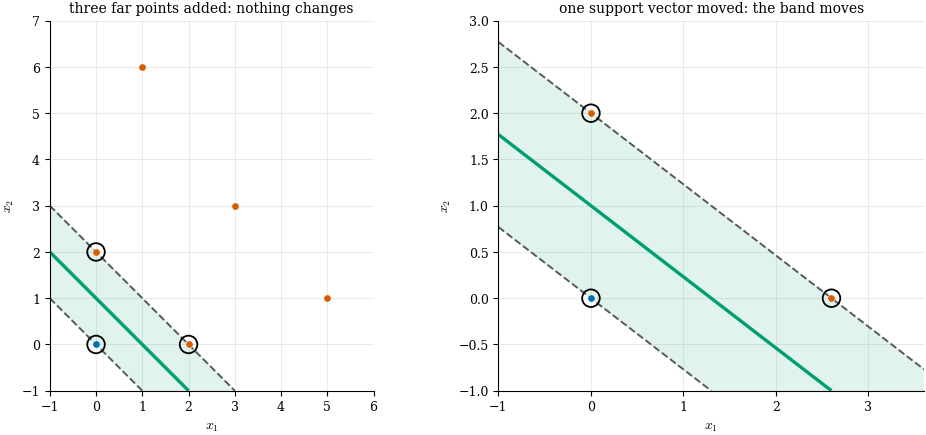

In [4]:
for far in ([3, 3], [5, 1], [1, 6], [4, 4]):
    Xf, yf = np.vstack([X3, far]), np.append(y3, 1)
    m = SVC(kernel="linear", C=1e6).fit(Xf, yf)
    margin_far = score(np.array([far], float), m.coef_[0], m.intercept_[0])[0]
    same = np.array_equal(m.coef_, svm3.coef_) and np.array_equal(m.intercept_, svm3.intercept_)
    print(f"add {far}: its margin {margin_far:5.2f} > 1 | (w, b) identical bit for bit? {same}"
          f" | support vectors {m.support_}")

X_nudged = X3.copy()
X_nudged[0] = [2.6, 0.0]                                 # move a SUPPORT vector instead
m2 = SVC(kernel="linear", C=1e6).fit(X_nudged, y3)
print(f"\nmove support vector x1 to (2.6, 0):  w {svm3.coef_[0].round(3)} -> {m2.coef_[0].round(3)},"
      f"  b {svm3.intercept_[0]:.3f} -> {m2.intercept_[0]:.3f}")

Xf, yf = np.vstack([X3, [3, 3], [5, 1], [1, 6]]), np.append(y3, [1, 1, 1])
mf = SVC(kernel="linear", C=1e6).fit(Xf, yf)
print("all three far points at once, (w, b) identical bit for bit?",
      np.array_equal(mf.coef_, svm3.coef_) and np.array_equal(mf.intercept_, svm3.intercept_))

fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.4))
draw_svm(axes[0], Xf, yf, mf.coef_[0], mf.intercept_[0], sv=mf.support_,
         title="three far points added: nothing changes", pad=1.0)
draw_svm(axes[1], X_nudged, y3, m2.coef_[0], m2.intercept_[0], sv=m2.support_,
         title="one support vector moved: the band moves", pad=1.0)
plt.show()

## 3. Real data overlaps: the soft margin

Most datasets cannot be separated, and then no $\mathbf{w}$ satisfies every $y_if(\mathbf{x}_i)\ge1$.
The soft margin gives each point a **slack** $\xi_i\ge0$ and charges for it:

$$\min_{\mathbf{w},b,\xi}\ \tfrac12\lVert\mathbf{w}\rVert^2+C\sum_i\xi_i
\quad\text{subject to}\quad y_if(\mathbf{x}_i)\ge1-\xi_i,\ \ \xi_i\ge0 .$$

For a fitted model the cheapest legal slack is $\xi_i=\max\big(0,\,1-y_if(\mathbf{x}_i)\big)$, which
sorts every point into one of three groups:

| slack | where the point is |
|---|---|
| $\xi_i=0$ | on or outside its own margin line &mdash; no charge |
| $0<\xi_i\le1$ | inside the band, but still on the correct side |
| $\xi_i>1$ | on the **wrong** side &mdash; misclassified |

on or outside the band (xi = 0)     : 128 points
inside, correct        (0 < xi <= 1):  39 points
wrong side             (xi > 1)     :  33 points

misclassified, counted from xi > 1 : 33
misclassified, counted by sklearn  : 33
every point with slack > 0 is a support vector: True
support vectors with zero slack (exactly on a margin line): 3


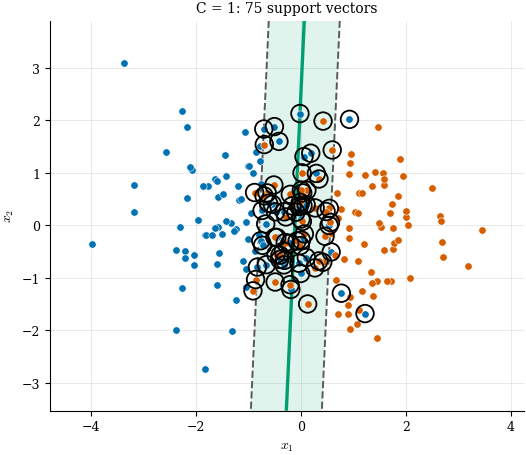

In [5]:
X, y = make_two_blobs(n=200, sep=0.9, seed=1)            # overlapping on purpose
svm = SVC(kernel="linear", C=1.0, tol=1e-8).fit(X, y)    # a tight tolerance keeps the checks crisp
w, b = svm.coef_[0], svm.intercept_[0]

m = y * score(X, w, b)                                   # functional margins
xi = np.maximum(0.0, 1.0 - m)                            # the slack, computed by hand
tol = 1e-6
groups = {"on or outside the band (xi = 0)     ": xi <= tol,
          "inside, correct        (0 < xi <= 1)": (xi > tol) & (xi <= 1),
          "wrong side             (xi > 1)     ": xi > 1}
for name, mask in groups.items():
    print(f"{name}: {mask.sum():3d} points")

print(f"\nmisclassified, counted from xi > 1 : {(xi > 1).sum()}")
print(f"misclassified, counted by sklearn  : {(svm.predict(X) != y).sum()}")
is_sv = np.isin(np.arange(len(y)), svm.support_)
print("every point with slack > 0 is a support vector:", bool(is_sv[xi > tol].all()))
print("support vectors with zero slack (exactly on a margin line):", int((is_sv & (xi <= tol)).sum()))

fig, ax = plt.subplots(figsize=(5.6, 4.6))
draw_svm(ax, X, y, w, b, sv=svm.support_, title=f"C = 1: {len(svm.support_)} support vectors")
plt.show()

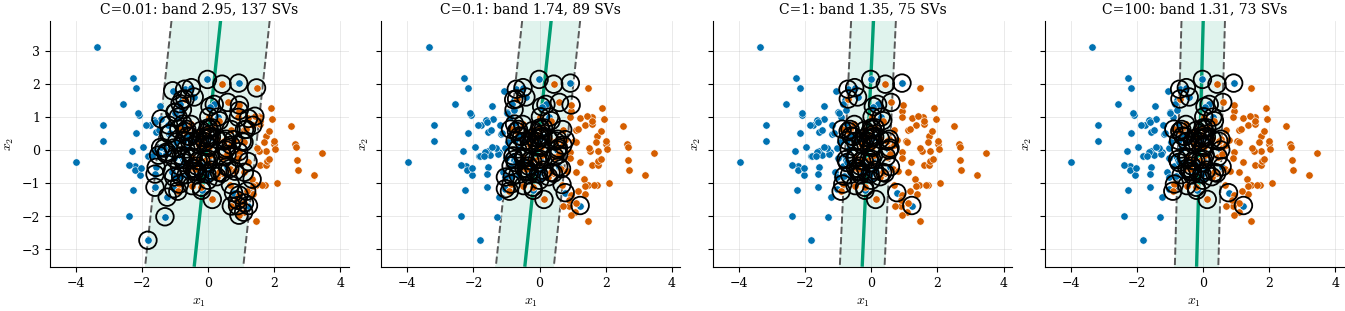

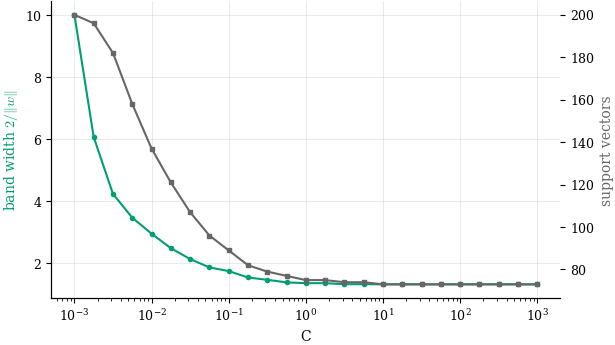

Small C: violations are cheap -> a wide, tolerant band with many support vectors.
Large C: violations are expensive -> a narrow band that chases individual points.


In [6]:
Cs = [0.01, 0.1, 1, 100]                                 # <-- CHANGE ME
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.7), sharex=True, sharey=True)
for ax, Cval in zip(axes, Cs):
    s = SVC(kernel="linear", C=Cval).fit(X, y)
    draw_svm(ax, X, y, s.coef_[0], s.intercept_[0], sv=s.support_,
             title=f"C={Cval:g}: band {2 / np.linalg.norm(s.coef_[0]):.2f}, {len(s.support_)} SVs")
plt.show()

grid = np.logspace(-3, 3, 25)
width, n_sv = [], []
for Cval in grid:
    s = SVC(kernel="linear", C=Cval).fit(X, y)
    width.append(2 / np.linalg.norm(s.coef_[0]))
    n_sv.append(len(s.support_))

fig, a1 = plt.subplots(figsize=(6.2, 3.5))
a1.semilogx(grid, width, "-o", ms=3, color=CG)
a1.set_xlabel("C"); a1.set_ylabel(r"band width $2/\|w\|$", color=CG)
a2 = a1.twinx(); a2.grid(False)
a2.semilogx(grid, n_sv, "-s", ms=3, color="0.4"); a2.set_ylabel("support vectors", color="0.4")
plt.show()
print("Small C: violations are cheap -> a wide, tolerant band with many support vectors.")
print("Large C: violations are expensive -> a narrow band that chases individual points.")

## 4. The hinge loss: the same problem, without constraints

Put the cheapest slack $\xi_i=\max(0,1-y_if(\mathbf{x}_i))$ back into the objective and the
constraints disappear:

$$\min_{\mathbf{w},b}\ \underbrace{\tfrac12\lVert\mathbf{w}\rVert^2}_{\text{L2 penalty}}
+C\sum_i\underbrace{\max\big(0,\,1-y_if(\mathbf{x}_i)\big)}_{\text{hinge loss}} .$$

That is the **loss + penalty** recipe of Sessions&nbsp;03&ndash;04 with a new loss. Two checks: the hinge
next to the losses you know, and a test that scikit-learn's answer really minimizes *this* objective
&mdash; if it does, every small random nudge of $(\mathbf{w},b)$ must make the objective worse.

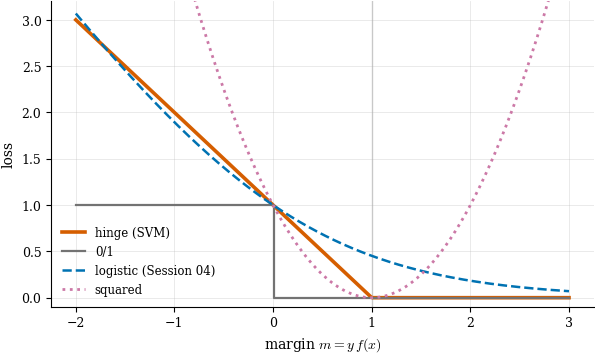

objective at sklearn's (w, b): 72.754390
best of 1000 random nudges   : 72.755106
every nudge made it worse    : True


In [7]:
mm = np.linspace(-2, 3, 400)
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(mm, np.maximum(0, 1 - mm), color=C1, lw=2.6, label="hinge (SVM)")
ax.step(mm, (mm < 0).astype(float), where="post", color="0.45", lw=1.6, label="0/1")
ax.plot(mm, np.log2(1 + np.exp(-mm)), "--", color=C0, lw=1.8, label="logistic (Session 04)")
ax.plot(mm, (1 - mm) ** 2, ":", color="#CC79A7", lw=2.0, label="squared")
ax.axvline(1, color="0.82", lw=1.0, zorder=0)
ax.set_xlabel(r"margin $m = y\,f(x)$"); ax.set_ylabel("loss"); ax.set_ylim(-0.1, 3.2)
ax.legend(fontsize=8.5)
plt.show()


def primal_objective(w, b, X, y, C):
    "(1/2)||w||^2 + C * (sum of hinge losses)"
    return 0.5 * w @ w + C * np.maximum(0.0, 1.0 - y * score(X, w, b)).sum()

J_star = primal_objective(w, b, X, y, C=1.0)
nudge = np.random.default_rng(0)
nudged = [primal_objective(w + 0.01 * nudge.normal(size=2), b + 0.01 * nudge.normal(), X, y, C=1.0)
          for _ in range(1000)]
print(f"objective at sklearn's (w, b): {J_star:.6f}")
print(f"best of 1000 random nudges   : {min(nudged):.6f}")
print("every nudge made it worse    :", bool(min(nudged) >= J_star - 1e-9))

## 5. Real data: breast cancer, and why scaling is not optional

The margin $2/\lVert\mathbf{w}\rVert$ folds every feature into a single length. If one column is measured
in thousands and another in thousandths, the big one dominates the geometry, and "the widest band" is
widest in the wrong units. The 30 breast-cancer measurements differ in scale by several orders of
magnitude. Compare the SVM with and without standardization at the **same** $C$, and only then tune $C$
by cross-validation. Watch for a second symptom too: without scaling the solver may never converge, and
then its accuracy just reflects wherever it happened to stop.

In [8]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
Xbc, ybc = data.data, np.where(data.target == 1, 1, -1)
stds = Xbc.std(axis=0)
print(f"feature standard deviations: {stds.min():.4f} to {stds.max():.1f}  "
      f"(a factor of {stds.max() / stds.min():,.0f})")

Xtr, Xte, ytr, yte = train_test_split(Xbc, ybc, test_size=0.3, random_state=0, stratify=ybc)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    raw = SVC(kernel="linear", C=1.0, max_iter=200_000).fit(Xtr, ytr)
never_converged = any(issubclass(wr.category, ConvergenceWarning) for wr in caught)
print(f"\nC = 1, unscaled : test accuracy {raw.score(Xte, yte):.3f}, {len(raw.support_)} support vectors"
      + ("   <-- the solver never converged" if never_converged else ""))

scaled = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0)).fit(Xtr, ytr)
print(f"C = 1, scaled   : test accuracy {scaled.score(Xte, yte):.3f}, "
      f"{len(scaled.named_steps['svc'].support_)} support vectors")

search = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel="linear")),
                      {"svc__C": np.logspace(-3, 2, 11)}, cv=5).fit(Xtr, ytr)
best = search.best_estimator_
print(f"\nthen tune C by 5-fold CV (scaled): best C = {search.best_params_['svc__C']:.3g}, "
      f"test accuracy {best.score(Xte, yte):.3f}")

feature standard deviations: 0.0026 to 568.9  (a factor of 215,171)

C = 1, unscaled : test accuracy 0.942, 44 support vectors   <-- the solver never converged
C = 1, scaled   : test accuracy 0.953, 27 support vectors

then tune C by 5-fold CV (scaled): best C = 0.316, test accuracy 0.959


## Recap & exercises

**Recap.**
* The SVM picks the separating line with the **widest band**; with the closest points scaled to
  functional margin $1$, the band is $2/\lVert\mathbf{w}\rVert$ wide.
* The **functional** margin $y_if(\mathbf{x}_i)$ has no units &mdash; rescaling $(\mathbf{w},b)$ changes it;
  the **geometric** margin $y_if(\mathbf{x}_i)/\lVert\mathbf{w}\rVert$ is a real distance and does not.
* Only **support vectors** matter: adding far points left `coef_` and `intercept_` identical bit for bit.
* The **soft margin** charges slack $\xi_i=\max(0,1-y_if(\mathbf{x}_i))$, and $C$ trades band width against
  violations (small $C$: wide and tolerant; large $C$: narrow and strict).
* Equivalently, **hinge loss + L2 penalty** &mdash; and sklearn's answer minimizes exactly that objective.
* **Standardize** first, and choose $C$ by cross-validation.

**Exercises.**
1. In &sect;1, refit with `tol=1e-8`, then (at the default tolerance) with `C=1` and with `C=0.9`. Which
   change moves sklearn onto $\mathbf{w}=(1,1)$, $b=-1$, which one changes the answer, and why?
   (Notebook&nbsp;06b's prices explain the last part.)
2. In &sect;2, add a point *inside* the band instead, e.g. `[0.6, 0.6]` labeled $+1$. Does `coef_` stay
   identical now? Which constraint became tight?
3. In &sect;3, plot the slack $\xi_i$ against the geometric margin $\gamma_i=y_if(\mathbf{x}_i)/\lVert\mathbf{w}\rVert$
   from &sect;1. Why is it piecewise linear, with its kink at $\gamma_i=1/\lVert\mathbf{w}\rVert$?
4. **Train it yourself.** Minimize the &sect;4 objective by sub-gradient descent: its sub-gradient is
   $\mathbf{w}-C\sum_{i:\,y_if(\mathbf{x}_i)<1}y_i\mathbf{x}_i$ (and $-C\sum_{i:\,y_if(\mathbf{x}_i)<1}y_i$
   for $b$). Compare your band width with sklearn's. Expect it to be close but not exact &mdash; why?
5. On breast cancer, which features get the largest $|w_j|$ after scaling? Are they the same without it?

*Next:* **06b &mdash; the dual and the kernel trick**: solve the SVM ourselves, meet the prices
$\alpha_i$, and see why inner products are all an SVM ever needs.